# Patient Segmentation with Clustering

Imagine you are managing a healthcare organization — a small clinic or a large hospital
network, a local practice or a major health system. Either way, it pays to **know your
patients**.

Machine learning offers a natural tool for this: **clustering**, the most common
unsupervised learning technique, groups similar individuals together without needing
any labeled outcome to predict.

**Distance-based clustering** groups points into clusters such that distances *within*
a cluster are small while distances *between* clusters are large.

This notebook segments 2,000 patients into meaningful groups using clustering, and
walks through:

- Exploring and cleaning real-world healthcare data (including disguised missing values)
- Why a naive clustering approach fails on mixed numeric/categorical data
- Building a distance measure and clustering method suited to mixed data
- Interpreting the resulting patient segments
- Assigning a brand-new patient to an existing segment

Throughout, I used an AI coding assistant to draft parts of the implementation —
validating, correcting, and rewriting its output where it fell short (see the
[README](../README.md) for more on that process and this project's origins).

**Dataset:** 2,000 synthetic patient records with demographics, clinical conditions,
insurance details, and visit/billing history (`data/patient_insurance_dataset.csv`).

## 1. Setup & Imports

I'm going to work with a CSV dataset for data exploration, visualization, and
clustering, so let's start by importing everything needed for data manipulation,
statistical summaries, visualization, and machine learning preprocessing.

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Statistical summaries
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Display settings for pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# For displaying multiple outputs in a cell
from IPython.display import display

## 2. Load & Explore the Dataset

In [2]:
patients_df = pd.read_csv('../data/patient_insurance_dataset.csv')

Let's get a first look at the data: shape, dtypes, summary statistics, and the
distribution of values in each categorical column.

In [3]:
# Show shape
print('Shape:', patients_df.shape)

# Show data types
print('\nData Types:')
print(patients_df.dtypes)

# Show statistical summary (include all columns)
display(patients_df.describe(include='all'))

# Show value counts for all categorical columns
categorical_cols = patients_df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f'\nValue counts for {col}:')
    display(patients_df[col].value_counts())

Shape: (2000, 16)

Data Types:
PatientID                  object
Age                         int64
Gender                     object
State                      object
City                       object
Height_cm                   int64
Weight_kg                   int64
BMI                       float64
Insurance_Type             object
Primary_Condition          object
Num_Chronic_Conditions      int64
Annual_Visits               int64
Avg_Billing_Amount        float64
Last_Visit_Date            object
Days_Since_Last_Visit       int64
Preventive_Care_Flag        int64
dtype: object


,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
count,2000,2000.00000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000,1505,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000.000000
unique,2000,NaN,2,10,20,NaN,NaN,NaN,4,9,NaN,NaN,NaN,364,NaN,NaN
top,P10000,NaN,Female,NC,Unknown,NaN,NaN,NaN,Medicare,Hypertension,NaN,NaN,NaN,2025-07-03,NaN,NaN
freq,1,NaN,1001,213,1012,NaN,NaN,NaN,906,210,NaN,NaN,NaN,13,NaN,NaN
mean,NaN,50.69550,NaN,NaN,NaN,167.907500,85.143500,30.740650,NaN,NaN,1.080000,5.466500,4000.270500,NaN,180.085000,0.464000
std,NaN,15.44445,NaN,NaN,NaN,12.684494,20.385428,8.839952,NaN,NaN,0.890504,3.485965,2463.239215,NaN,104.688484,0.498827
min,NaN,18.00000,NaN,NaN,NaN,145.000000,50.000000,13.400000,NaN,NaN,0.000000,1.000000,207.000000,NaN,1.000000,0.000000
25%,NaN,40.00000,NaN,NaN,NaN,158.000000,67.000000,23.800000,NaN,NaN,1.000000,3.000000,2061.000000,NaN,90.000000,0.000000
50%,NaN,51.00000,NaN,NaN,NaN,168.000000,86.000000,30.100000,NaN,NaN,1.000000,4.000000,3707.250000,NaN,183.000000,0.000000
75%,NaN,63.25000,NaN,NaN,NaN,177.000000,103.000000,37.025000,NaN,NaN,1.000000,8.000000,5650.875000,NaN,268.000000,1.000000



Value counts for PatientID:


PatientID
P10000    1
P10001    1
P10002    1
P10003    1
P10004    1
         ..
P11995    1
P11996    1
P11997    1
P11998    1
P11999    1
Name: count, Length: 2000, dtype: int64


Value counts for Gender:


...

Insurance_Type
Medicare    906
Private     545
Medicaid    483
Self-Pay     66
Name: count, dtype: int64


Value counts for Primary_Condition:


Primary_Condition
Hypertension     210
Obesity          183
Anxiety          175
Arthritis        163
Asthma           160
Depression       160
Diabetes         158
Heart Disease    150
COPD             146
Name: count, dtype: int64


Value counts for Last_Visit_Date:


Last_Visit_Date
2025-07-03    13
2025-11-27    13
2025-07-15    12
2025-12-25    12
2025-09-24    12
              ..
2025-07-28     1
2025-09-25     1
2025-04-09     1
2025-05-22     1
2025-04-22     1
Name: count, Length: 364, dtype: int64

## 3. Data Cleaning

One of the things necessary is to determine whether you have missing values. Handling
missing values is always difficult. If only a few observations are missing, they can
be excluded. If there is a significant number of missing values, several options are
available depending on the type of missing value.

But here's the catch: missing values don't always show up as `NaN`. Sometimes they
hide as strings like `"Unknown"`, `"None"`, `"N/A"`, or even blank spaces. An AI
assistant (or even pandas) won't flag these automatically — you need to check for
them yourself.

### Check for missing values

In [4]:
# Check for missing (NaN) values in each column
missing_counts = patients_df.isna().sum()
missing_percent = (missing_counts / len(patients_df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent.round(2)
})

print('Missing values summary:')
display(missing_summary)

Missing values summary:


,Missing Count,Missing Percent
PatientID,0,0.00
Age,0,0.00
Gender,0,0.00
State,0,0.00
City,0,0.00
Height_cm,0,0.00
Weight_kg,0,0.00
BMI,0,0.00
Insurance_Type,0,0.00
Primary_Condition,495,24.75


When I first asked an AI assistant to check for missing values, it reported that the
dataset has none. Is that actually correct?

Re-checking the value counts from the previous step tells a different story: the
**City** column has values recorded as `"Unknown"`, and **Primary_Condition** has
`"None"` as a value. Pandas didn't flag these as missing because, technically,
they're valid strings — but `"Unknown"` isn't a real city. It's a disguised missing
value.

This is a very common problem in real-world data, especially in healthcare. Missing
data is sometimes filled with placeholder text like `"Unknown"`, `"None"`,
`"Not Specified"`, or `"N/A"` instead of being left as an actual null value.

**The AI missed this** — it only checked for literal `NaN` values.

In [5]:
# Define placeholder values to consider as missing
missing_placeholders = ["Unknown", "None"]

# Replace placeholder values with np.nan
patients_df_replaced = patients_df.replace(missing_placeholders, np.nan)

# Save the result in df_with_na
df_with_na = patients_df_replaced.copy()

# Check for missing values again
missing_counts = df_with_na.isna().sum()
missing_percent = (missing_counts / len(df_with_na)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent.round(2)
})

print('Missing values summary (including placeholders as missing):')
display(missing_summary)

Missing values summary (including placeholders as missing):


,Missing Count,Missing Percent
PatientID,0,0.00
Age,0,0.00
Gender,0,0.00
State,0,0.00
City,1012,50.60
Height_cm,0,0.00
Weight_kg,0,0.00
BMI,0,0.00
Insurance_Type,0,0.00
Primary_Condition,495,24.75


Now the true picture of missing data emerges. The **City** column has ~50% missing,
which is too high to impute reliably — I'll drop it from later modeling.

**Primary_Condition** is missing for 495 patients. On closer inspection, whenever a
condition *is* present it always names a disease or health condition. Since a missing
Primary_Condition simply means the patient has no recorded condition, I'll fill those
missing values with `'No Condition'` rather than dropping them — the absence of a
condition is itself meaningful information for segmentation.

In [6]:
# Fill missing values in 'Primary_Condition' with 'No Condition'
patient_df_nonan = df_with_na.copy()
patient_df_nonan['Primary_Condition'] = patient_df_nonan['Primary_Condition'].fillna('No Condition')

# Verify the replacement
missing_primary_condition = patient_df_nonan['Primary_Condition'].isna().sum()
unique_primary_conditions = patient_df_nonan['Primary_Condition'].unique()

print(f"Missing values in 'Primary_Condition' after filling: {missing_primary_condition}")
print(f"Unique values in 'Primary_Condition': {unique_primary_conditions}")

Missing values in 'Primary_Condition' after filling: 0
Unique values in 'Primary_Condition': ['Arthritis' 'Depression' 'Asthma' 'Hypertension' 'Anxiety' 'No Condition'
 'Heart Disease' 'Obesity' 'COPD' 'Diabetes']


## 4. Exploratory Data Analysis

It's important to get descriptive statistics and the distribution of each variable of
interest. Looking at distributions and descriptive statistics helps us understand the
patient population and determine what data transformations are needed before
clustering.

- For numerical variables, we need visualizations that reveal the spread and
  potential outliers in each feature, as well as the correlations between them.
- For categorical variables, we need counts that show how these categories are
  distributed across the dataset.

To understand the spread of each numeric feature and check for outliers, I'll plot
histograms with KDE curves for the numeric columns, count plots for the key
categorical columns, and a correlation heatmap (lower triangle only, annotated) to
check for redundant features before clustering.

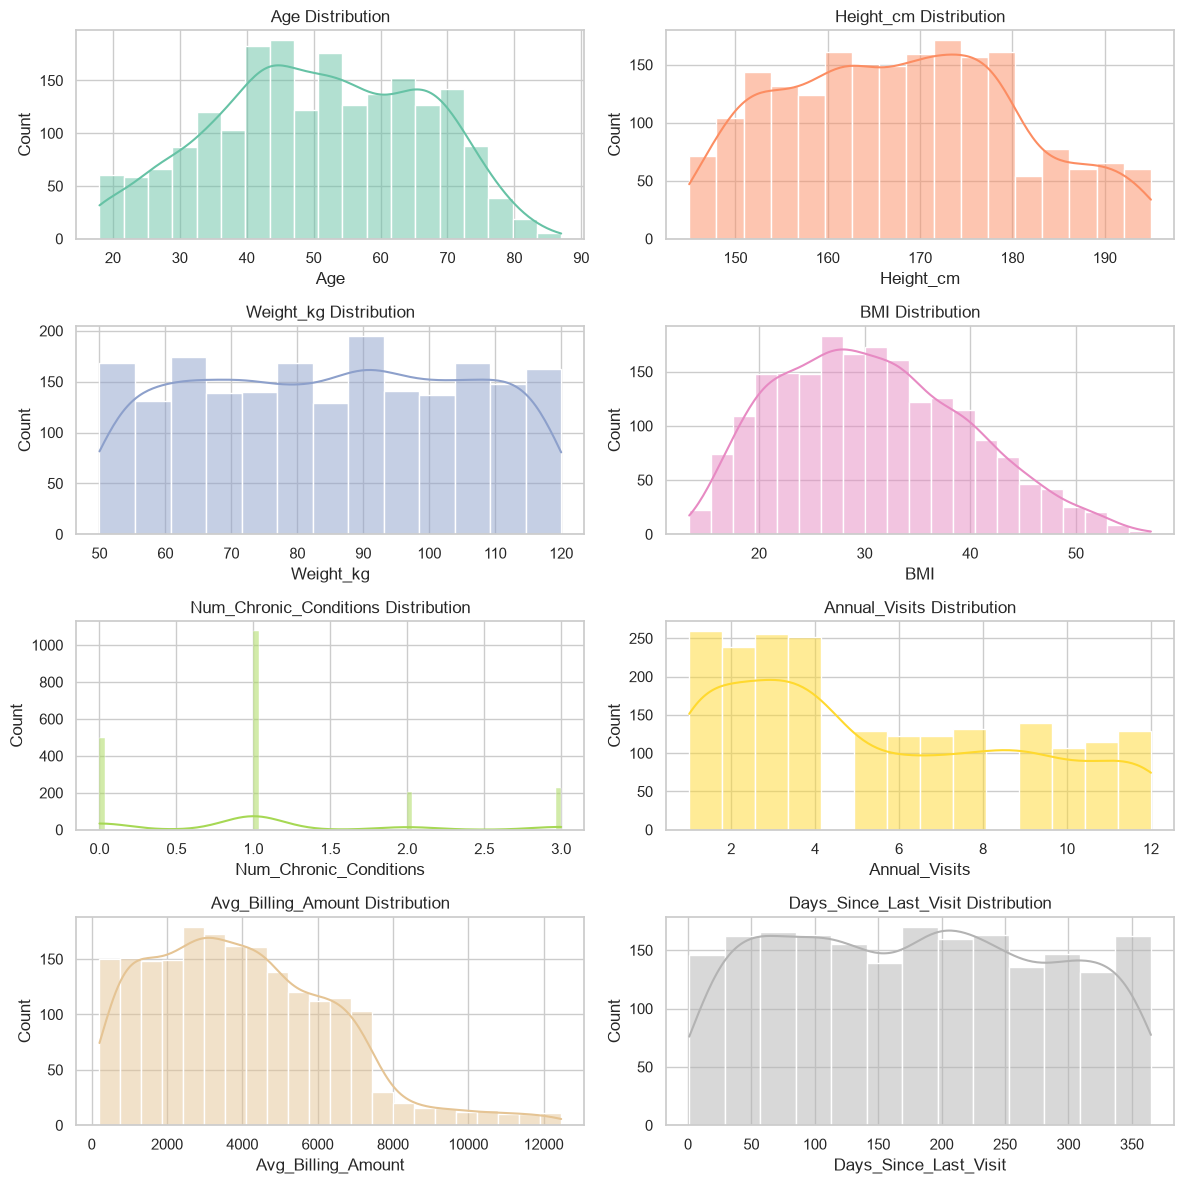

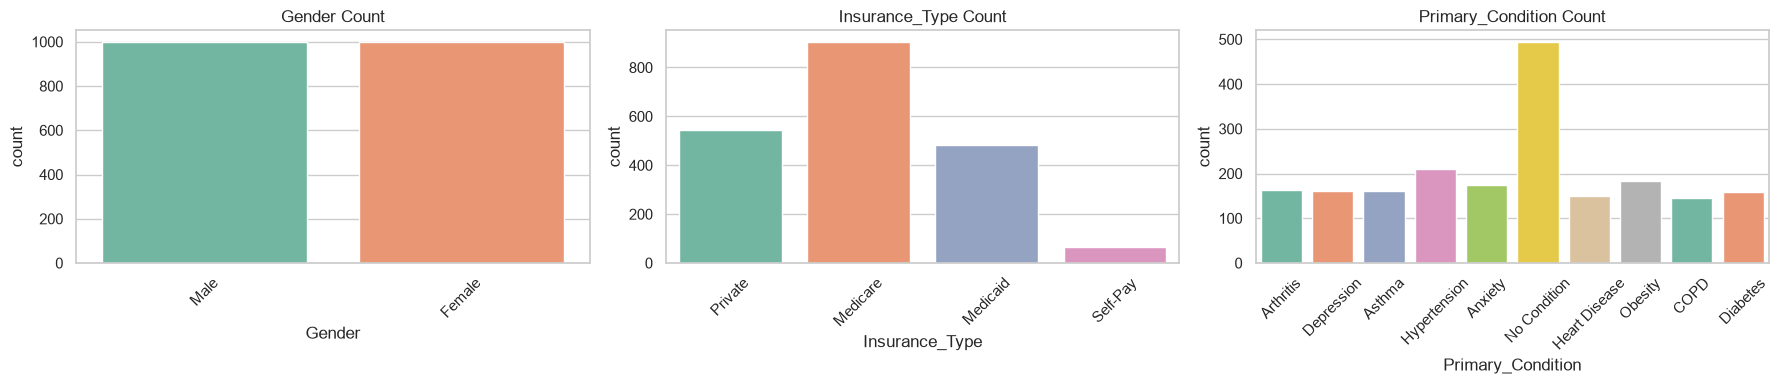

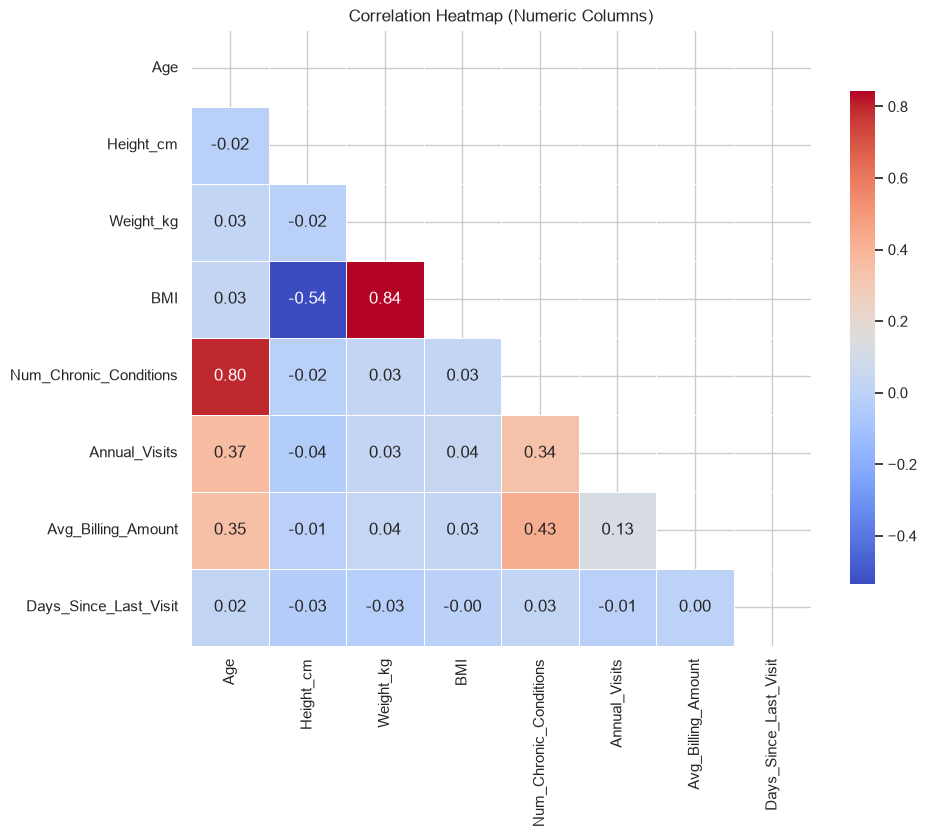

In [7]:
# Set style and palette
sns.set(style="whitegrid", palette="Set2")

# Select numeric and categorical columns
numeric_cols = [
    'Age', 'Height_cm', 'Weight_kg', 'BMI', 'Num_Chronic_Conditions',
    'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Plot grid of histograms with KDE for numeric columns
n_num = len(numeric_cols)
fig, axes = plt.subplots(nrows=(n_num + 1) // 2, ncols=2, figsize=(12, 3 * ((n_num + 1) // 2)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(patient_df_nonan[col], kde=True, ax=axes[i], color=sns.color_palette("Set2")[i % 8])
    axes[i].set_title(f"{col} Distribution")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# Count plots for categorical columns
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=patient_df_nonan[col], hue=patient_df_nonan[col], legend=False, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Count")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric columns
corr = patient_df_nonan[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

The correlation heatmap shows how numeric features relate to each other. This helps
us understand which features move together and whether any are redundant. Highly
correlated features can bias clustering by effectively double-counting the same
information.

The correlation heatmap reveals a few important relationships:

- **Age and Num_Chronic_Conditions** are strongly correlated (r = 0.80). Older
  patients tend to accumulate more chronic conditions.
- **Weight_kg and BMI** are strongly correlated (r = 0.84), and **Height_cm and BMI**
  show a moderate negative correlation (r = -0.54). Since BMI is derived from height
  and weight, I'll keep only BMI to avoid redundancy.
- **Age, Num_Chronic_Conditions, Annual_Visits, and Avg_Billing_Amount** form a
  cluster of moderate positive correlations (r = 0.34-0.43) — older, sicker patients
  visit more and cost more.
- **Days_Since_Last_Visit** shows near-zero correlation with everything else; it
  captures an independent dimension of patient behavior.

## 5. Clustering

My first instinct for clustering patients — and what most AI assistants will suggest
by default — is **K-Means**.

Based on the correlation analysis, I'll select six numeric features (dropping
Height/Weight in favor of BMI) plus three categorical features to use for clustering.

In [8]:
# Select specified numerical and categorical columns
numerical_cols = [
    'Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = [
    'Gender', 'Insurance_Type', 'Primary_Condition'
]
selected_cols = numerical_cols + categorical_cols

patients_final_df = patient_df_nonan[selected_cols].copy()

# Display the first few rows to verify
patients_final_df.head()

,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Gender,Insurance_Type,Primary_Condition
0,64,50.4,3,7,2995.0,186,Male,Private,Arthritis
1,59,19.0,1,8,1209.0,39,Male,Medicare,Depression
2,58,37.4,1,4,999.0,126,Female,Private,Asthma
3,43,39.8,1,6,5638.5,286,Female,Medicare,Hypertension
4,53,18.3,1,4,5796.0,319,Female,Medicaid,Asthma


Let's cluster the patients using K-Means. I'll preprocess the data with a
`ColumnTransformer` — scaling the numeric features and one-hot encoding the
categorical ones (using `sparse_output=False` so we get a dense array) — then use
the elbow method to choose the number of clusters *k*.

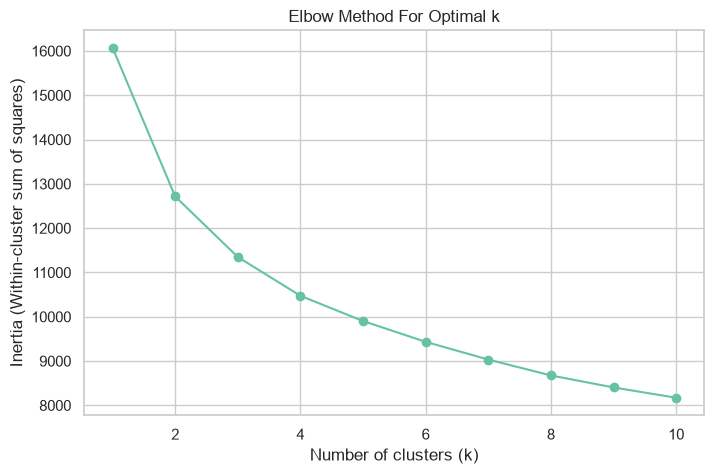

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

# Define columns
numerical_cols = [
    'Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = [
    'Gender', 'Insurance_Type', 'Primary_Condition'
]

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(sparse_output=False), categorical_cols)
])

# Prepare data for clustering
X = preprocessor.fit_transform(patients_final_df)

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

The elbow plot doesn't show a dramatic bend, but k=3 looks like a reasonable choice.
Let's fit K-Means with k=3, reduce the result to 2D with PCA, and visualize the
clusters.

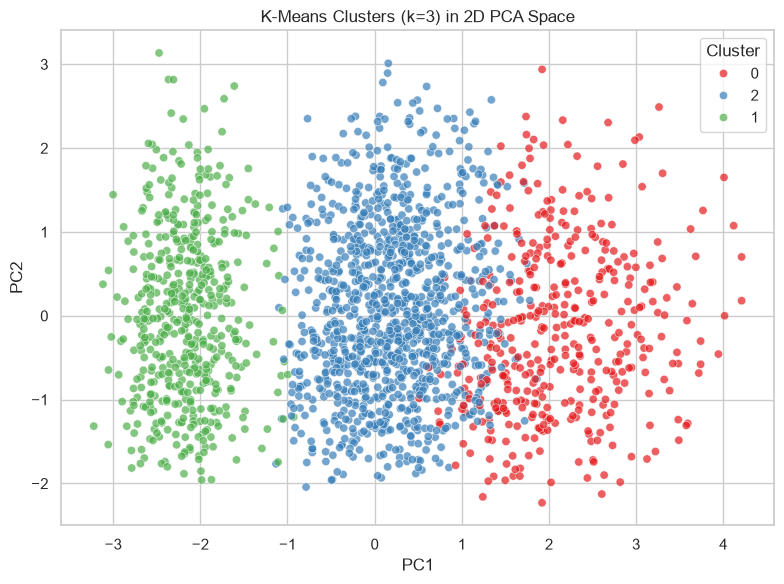

In [10]:
from sklearn.decomposition import PCA

# Fit KMeans with k=3 (chosen from the elbow plot above)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels.astype(str)
})

# Plot the clusters in 2D PCA space
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', alpha=0.7)
plt.title(f'K-Means Clusters (k={optimal_k}) in 2D PCA Space')
plt.tight_layout()
plt.show()

K-Means is the most popular clustering algorithm — elegant and fast. But it has a
fundamental limitation: it uses Euclidean distance, which only works well with
numeric data.

In my case, K-Means only found 2 visually meaningful clusters, and the elbow method
picked k=2 as "best." But does that really mean patients only fall into 2 groups?

No — here's what went wrong:

- **One-hot encoding** converted 3 categorical columns into ~15 binary columns,
  inflating dimensionality.
- **Euclidean distance** treats every binary column equally — a 0/1 difference in
  "Gender_Male" weighs the same as a real numeric difference in Age.
- **Categorical similarity is lost**: "Private" vs "Medicare" insurance are treated
  as completely unrelated, when they actually carry meaningful similarity structure.
- **Sparse, high-dimensional space**: K-Means struggles here — centroids become
  meaningless.

I need a distance measure that handles mixed data properly. **Gower distance**
(1971) was designed precisely for this problem. It computes a distance between 0
and 1 for each feature, using the appropriate method for each data type:

- **Numeric features:** normalized Manhattan distance (range-scaled)
- **Categorical features:** simple matching (0 if same, 1 if different)
- **Final distance:** weighted average across all features

This means each feature contributes equally regardless of type, and there's no need
for one-hot encoding.

With a proper distance matrix in hand, I can use hierarchical (agglomerative)
clustering with **average linkage**, which works directly on a precomputed distance
matrix. Hierarchical clustering:

- Works with any distance matrix, including Gower distances.
- Doesn't require specifying the number of clusters upfront.
- Produces a dendrogram: a tree showing how patients merge into clusters step by
  step.

Since K-Means isn't suited to this mixed-type data, let's compute a Gower distance
matrix instead, using the `gower` library — installing it first if it isn't already
available.

In [11]:
# Install gower if not already installed
import sys
import subprocess

try:
    import gower
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gower'])
    import gower

In [12]:
# Compute Gower distance matrix for patients_final_df
gower_dist_matrix = gower.gower_matrix(patients_final_df)

# Show the shape and a preview of the distance matrix
print(f"Gower distance matrix shape: {gower_dist_matrix.shape}")
np.set_printoptions(precision=3, suppress=True)
print(gower_dist_matrix[:5, :5])

Gower distance matrix shape: (2000, 2000)
[[0.    0.455 0.406 0.533 0.603]
 [0.455 0.    0.451 0.437 0.512]
 [0.406 0.451 0.    0.364 0.27 ]
 [0.533 0.437 0.364 0.    0.325]
 [0.603 0.512 0.27  0.325 0.   ]]


With a proper distance matrix in hand, I'll run agglomerative (hierarchical)
clustering with average linkage directly on the precomputed Gower distances, trying
cluster counts from 2 to 10 and picking the one with the highest silhouette score.

In [13]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Range of clusters to try
range_n_clusters = range(2, 11)
silhouette_scores = []

for n_clusters in range_n_clusters:
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='precomputed',
        linkage='average',
        compute_full_tree=True
    )
    cluster_labels = clusterer.fit_predict(gower_dist_matrix)
    score = silhouette_score(gower_dist_matrix, cluster_labels, metric='precomputed')
    silhouette_scores.append(score)

# Find the best number of clusters
best_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Best number of clusters: {best_n_clusters}")
print(f"Silhouette scores: {silhouette_scores}")

Best number of clusters: 6
Silhouette scores: [0.24497440457344055, 0.18025265634059906, 0.22623483836650848, 0.2516862154006958, 0.26967957615852356, 0.25263479351997375, 0.26632142066955566, 0.25360286235809326, 0.24595744907855988]


In [14]:
# Fit final model with the best number of clusters
final_clusterer = AgglomerativeClustering(
    n_clusters=best_n_clusters,
    metric='precomputed',
    linkage='average',
    compute_full_tree=True
)
final_labels = final_clusterer.fit_predict(gower_dist_matrix)

# Add cluster labels to the DataFrame
patients_final_df['Cluster'] = final_labels
patients_final_df.head()

,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Gender,Insurance_Type,Primary_Condition,Cluster
0,64,50.4,3,7,2995.0,186,Male,Private,Arthritis,1
1,59,19.0,1,8,1209.0,39,Male,Medicare,Depression,5
2,58,37.4,1,4,999.0,126,Female,Private,Asthma,1
3,43,39.8,1,6,5638.5,286,Female,Medicare,Hypertension,4
4,53,18.3,1,4,5796.0,319,Female,Medicaid,Asthma,0


## 6. Dendrogram and Cluster Profiles

Let's visualize the hierarchical structure with a dendrogram, then summarize each
cluster's profile based on the features in `patients_final_df`.

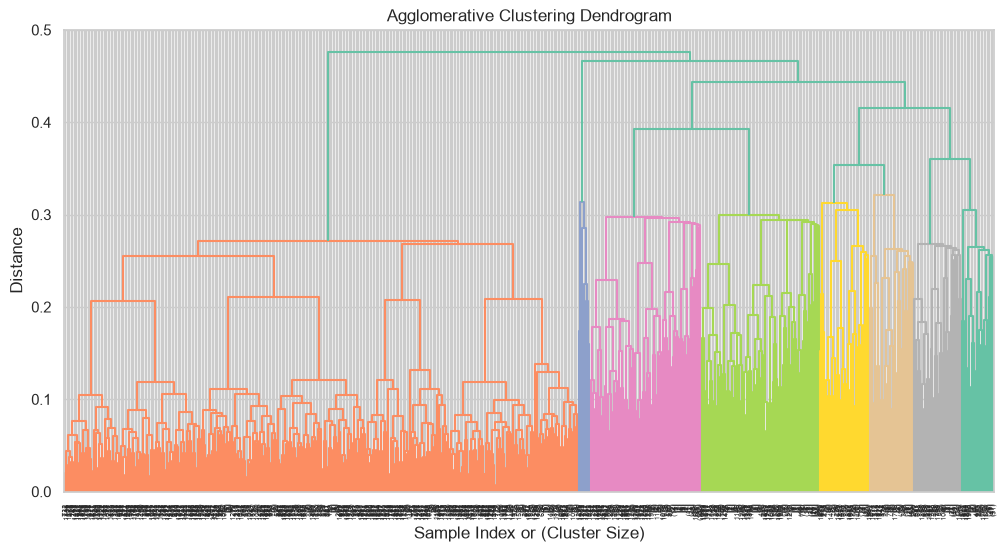

In [15]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# Compute linkage matrix for dendrogram (using the same distance matrix and linkage method)
linkage_matrix = sch.linkage(squareform(gower_dist_matrix), method='average')

plt.figure(figsize=(12, 6))
dendro = sch.dendrogram(linkage_matrix, truncate_mode='level', p=10)
plt.title('Agglomerative Clustering Dendrogram')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.show()

In [16]:
# Cluster profiles: summarize each cluster
cluster_profiles = patients_final_df.groupby('Cluster').agg({
    'Age': ['mean', 'std'],
    'BMI': ['mean', 'std'],
    'Num_Chronic_Conditions': ['mean', 'std'],
    'Annual_Visits': ['mean', 'std'],
    'Avg_Billing_Amount': ['mean', 'std'],
    'Days_Since_Last_Visit': ['mean', 'std'],
    'Gender': lambda x: x.value_counts().index[0],
    'Insurance_Type': lambda x: x.value_counts().index[0],
    'Primary_Condition': lambda x: x.value_counts().index[0]
})

# Clean up column names
cluster_profiles.columns = ['_'.join(col).strip() for col in cluster_profiles.columns.values]
cluster_profiles.reset_index(inplace=True)
cluster_profiles

,Cluster,Age_mean,Age_std,BMI_mean,BMI_std,Num_Chronic_Conditions_mean,Num_Chronic_Conditions_std,Annual_Visits_mean,Annual_Visits_std,Avg_Billing_Amount_mean,Avg_Billing_Amount_std,Days_Since_Last_Visit_mean,Days_Since_Last_Visit_std,Gender_<lambda>,Insurance_Type_<lambda>,Primary_Condition_<lambda>
0,0,51.070740,7.112561,30.544051,8.422804,1.147910,0.458596,6.498392,3.494581,4317.773312,2224.238221,188.395498,107.308875,Male,Medicaid,Depression
1,1,51.577428,7.183857,31.406299,8.986983,1.170604,0.491803,6.682415,3.451381,3956.598425,2146.305519,182.333333,103.922956,Male,Private,Hypertension
2,2,62.375000,1.597990,22.687500,4.676518,2.750000,0.462910,2.000000,1.069045,8884.812500,2802.505880,131.125000,114.690188,Male,Private,Depression
3,3,30.402020,6.393158,29.886263,8.828389,0.000000,0.000000,2.511111,1.092567,2598.311111,1393.221546,173.494949,103.657132,Male,Medicaid,No Condition
4,4,62.578454,11.367333,32.654333,9.179555,1.655738,0.831303,6.625293,3.442365,4932.629977,2715.172464,186.639344,103.144691,Female,Medicare,Obesity
5,5,62.402116,11.388122,29.358995,8.245123,1.661376,0.828306,6.026455,3.388127,4462.365079,2840.915050,173.243386,105.579487,Male,Medicare,Hypertension


The dendrogram shows how patients are progressively merged into clusters — the
height of each merge represents the distance between the groups being combined, and
cutting the tree at different heights yields different numbers of clusters. The
silhouette score computed earlier is what determined *where* to cut it. To
understand what each cluster actually means, the table above summarizes the average
numeric features and most common categorical values per cluster.

Let's also look at the distribution of each numeric feature within each cluster, as
a 2x3 grid of box plots.

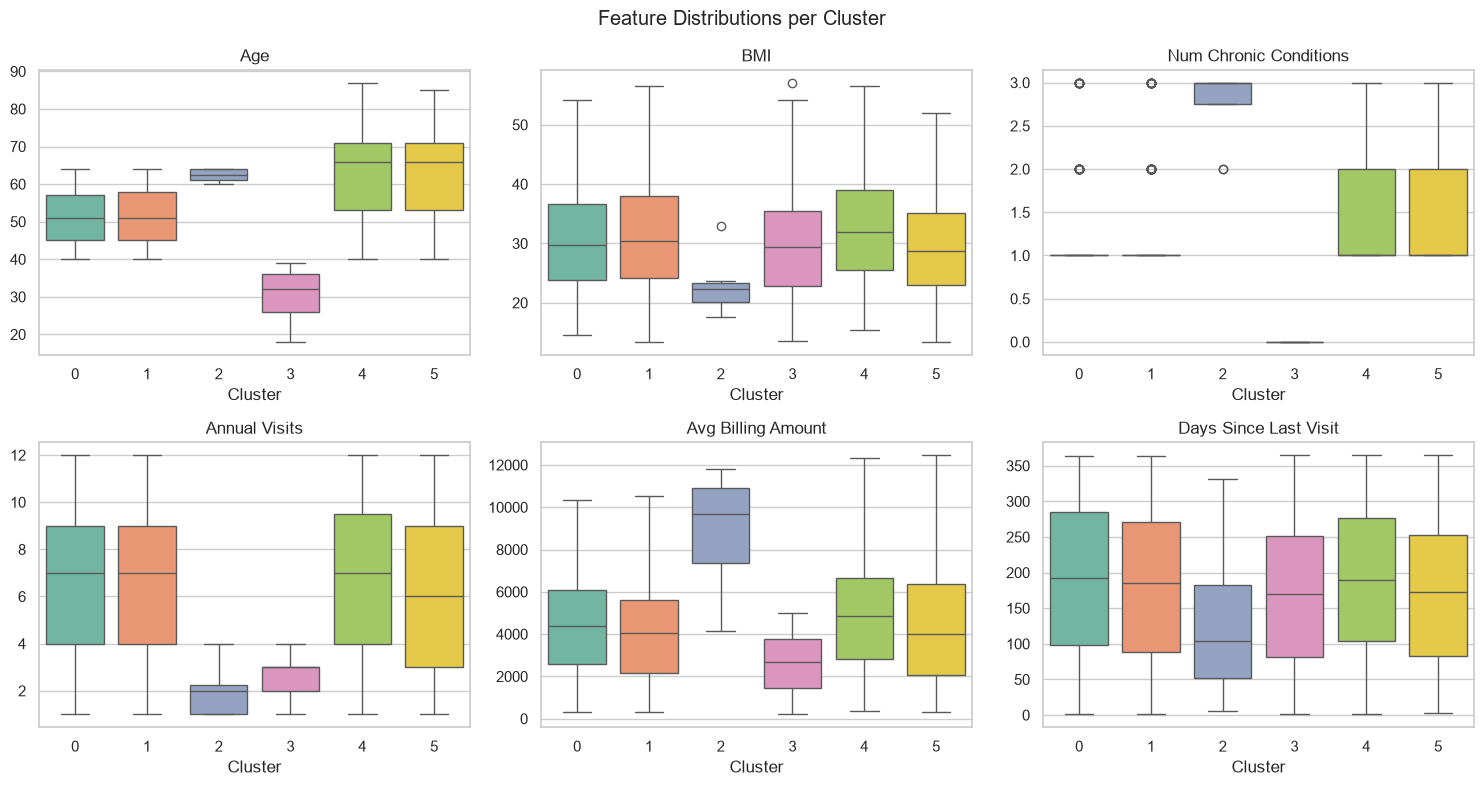

In [17]:
# List of numeric features to plot (raw per-patient values, not per-cluster means,
# so the boxes show real within-cluster spread rather than a single point)
numeric_features = [
    'Age', 'BMI', 'Num_Chronic_Conditions',
    'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        data=patients_final_df, x='Cluster', y=feature,
        hue='Cluster', palette='Set2', legend=False, ax=axes[i]
    )
    axes[i].set_title(feature.replace('_', ' '))
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')

fig.suptitle('Feature Distributions per Cluster')
plt.tight_layout()
plt.show()

## 7. Patient Segment Narratives

Based on the cluster profiles above, here are the patient segments we discovered.
For each cluster, I'll generate a markdown summary — patient count and share of the
population, mean of each numeric feature, and the most common value of each
categorical feature — so the result reads clearly for a non-technical stakeholder.
That's what makes clustering actionable.

In [18]:
from IPython.display import Markdown

def cluster_narrative(profile):
    numeric_cols = [
        'Age_mean', 'BMI_mean', 'Num_Chronic_Conditions_mean',
        'Annual_Visits_mean', 'Avg_Billing_Amount_mean', 'Days_Since_Last_Visit_mean'
    ]
    categorical_cols = [
        'Gender_<lambda>', 'Insurance_Type_<lambda>', 'Primary_Condition_<lambda>'
    ]
    cluster_counts = profile['Cluster'].value_counts().sort_index()
    total = cluster_counts.sum()
    for idx, row in profile.iterrows():
        cluster = row['Cluster']
        count = cluster_counts[cluster]
        percent = 100 * count / total
        # Prepare markdown table
        md = f"### Cluster {cluster}: Segment Overview\n"
        md += f"**Number of patients:** {count} ({percent:.1f}%)\n\n"
        md += "| Feature | Value |\n|---|---|\n"
        for col in numeric_cols:
            pretty = col.replace('_mean', '').replace('_', ' ')
            md += f"| {pretty} | {row[col]:.2f} |\n"
        for col in categorical_cols:
            pretty = col.replace('_<lambda>', '').replace('_', ' ')
            md += f"| Most common {pretty} | {row[col]} |\n"
        display(Markdown(md))

cluster_narrative(cluster_profiles)

### Cluster 0: Segment Overview
**Number of patients:** 1 (16.7%)

| Feature | Value |
|---|---|
| Age | 51.07 |
| BMI | 30.54 |
| Num Chronic Conditions | 1.15 |
| Annual Visits | 6.50 |
| Avg Billing Amount | 4317.77 |
| Days Since Last Visit | 188.40 |
| Most common Gender | Male |
| Most common Insurance Type | Medicaid |
| Most common Primary Condition | Depression |


### Cluster 1: Segment Overview
**Number of patients:** 1 (16.7%)

| Feature | Value |
|---|---|
| Age | 51.58 |
| BMI | 31.41 |
| Num Chronic Conditions | 1.17 |
| Annual Visits | 6.68 |
| Avg Billing Amount | 3956.60 |
| Days Since Last Visit | 182.33 |
| Most common Gender | Male |
| Most common Insurance Type | Private |
| Most common Primary Condition | Hypertension |


### Cluster 2: Segment Overview
**Number of patients:** 1 (16.7%)

| Feature | Value |
|---|---|
| Age | 62.38 |
| BMI | 22.69 |
| Num Chronic Conditions | 2.75 |
| Annual Visits | 2.00 |
| Avg Billing Amount | 8884.81 |
| Days Since Last Visit | 131.12 |
| Most common Gender | Male |
| Most common Insurance Type | Private |
| Most common Primary Condition | Depression |


### Cluster 3: Segment Overview
**Number of patients:** 1 (16.7%)

| Feature | Value |
|---|---|
| Age | 30.40 |
| BMI | 29.89 |
| Num Chronic Conditions | 0.00 |
| Annual Visits | 2.51 |
| Avg Billing Amount | 2598.31 |
| Days Since Last Visit | 173.49 |
| Most common Gender | Male |
| Most common Insurance Type | Medicaid |
| Most common Primary Condition | No Condition |


### Cluster 4: Segment Overview
**Number of patients:** 1 (16.7%)

| Feature | Value |
|---|---|
| Age | 62.58 |
| BMI | 32.65 |
| Num Chronic Conditions | 1.66 |
| Annual Visits | 6.63 |
| Avg Billing Amount | 4932.63 |
| Days Since Last Visit | 186.64 |
| Most common Gender | Female |
| Most common Insurance Type | Medicare |
| Most common Primary Condition | Obesity |


### Cluster 5: Segment Overview
**Number of patients:** 1 (16.7%)

| Feature | Value |
|---|---|
| Age | 62.40 |
| BMI | 29.36 |
| Num Chronic Conditions | 1.66 |
| Annual Visits | 6.03 |
| Avg Billing Amount | 4462.37 |
| Days Since Last Visit | 173.24 |
| Most common Gender | Male |
| Most common Insurance Type | Medicare |
| Most common Primary Condition | Hypertension |


## 8. Predicting the Segment for a New Patient

The clustering is done and our segments are defined. But here's a real-world
question: **what happens when a new patient enrolls tomorrow?**

We need to be able to assign them to the right segment without re-running the
entire clustering.

The idea is simple: compute the Gower distance from the new patient to every
existing patient, then see which cluster they're closest to on average.

I'll write a function that computes the Gower-style distance from a new patient to
every existing patient, averages that distance within each cluster, and returns the
closest one. Then I'll test it on a sample patient: a 55-year-old female on Medicare
with hypertension, BMI 32, 2 chronic conditions, 6 annual visits, $3,500 average
billing, and 120 days since their last visit.

In [19]:
def gower_distance(new_patient_dict, df, numeric_cols, categorical_cols, cluster_labels):
    """
    Compute Gower distance from a new patient to all existing patients, then average by cluster.
    Args:
        new_patient_dict: dict of new patient's features
        df: original DataFrame (without cluster labels)
        numeric_cols: list of numeric column names
        categorical_cols: list of categorical column names
        cluster_labels: array-like of cluster assignments for df
    Returns:
        closest_cluster: int, the closest cluster label
        cluster_distances: dict, average distance to each cluster
    """
    # Convert new patient dict to DataFrame
    new_patient_df = pd.DataFrame([new_patient_dict])
    # Numeric part: min-max scale using df's min/max
    scaler = MinMaxScaler()
    scaler.fit(df[numeric_cols])
    df_num_scaled = scaler.transform(df[numeric_cols])
    new_num_scaled = scaler.transform(new_patient_df[numeric_cols])
    # Categorical part: 0 if same, 1 if different
    cat_dist = (df[categorical_cols].values != new_patient_df[categorical_cols].values).astype(float)
    # Numeric distance: abs diff
    num_dist = np.abs(df_num_scaled - new_num_scaled)
    # Combine: average over all features
    all_dist = np.concatenate([num_dist, cat_dist], axis=1)
    gower_distances = all_dist.mean(axis=1)
    # Average by cluster
    cluster_distances = {}
    for cluster in np.unique(cluster_labels):
        cluster_distances[cluster] = gower_distances[cluster_labels == cluster].mean()
    closest_cluster = min(cluster_distances, key=cluster_distances.get)
    return closest_cluster, cluster_distances

# Use the real cluster assignments from the agglomerative clustering fit above
cluster_labels = final_labels

# Define column lists
numeric_cols = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit']
categorical_cols = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Sample patient: 55-year-old female, Medicare, Hypertension
sample_patient = {
    'Age': 55,
    'Gender': 'Female',
    'Insurance_Type': 'Medicare',
    'Primary_Condition': 'Hypertension',
    'BMI': 32,
    'Num_Chronic_Conditions': 2,
    'Annual_Visits': 6,
    'Avg_Billing_Amount': 3500,
    'Days_Since_Last_Visit': 120
}

closest_cluster, cluster_distances = gower_distance(
    sample_patient, patients_final_df, numeric_cols, categorical_cols, cluster_labels
)

print(f"Closest cluster: {closest_cluster}")
display(cluster_distances)

Closest cluster: 4


{np.int64(0): np.float64(0.4122696343645364),
 np.int64(1): np.float64(0.40446264636037593),
 np.int64(2): np.float64(0.49943964894179604),
 np.int64(3): np.float64(0.4672146161675059),
 np.int64(4): np.float64(0.24819628045761774),
 np.int64(5): np.float64(0.35201719962384437)}

## 9. Key Takeaways

1. **Always explore your data first** — distributions, missing values, and
   correlations tell you what preprocessing is needed.
2. **AI-assisted coding accelerates your workflow**, but your domain knowledge is
   irreplaceable. You need to validate and sometimes correct the AI.
3. **Algorithm choice matters**: K-Means with one-hot encoding failed because
   Euclidean distance doesn't handle mixed data well. Gower distance was the right
   tool for this dataset.
4. **Clustering is only useful if you can interpret it**: the real value is in the
   patient segment narratives that inform clinical and business decisions.
5. **Practice!** The best way to learn is by doing.